<a href="https://colab.research.google.com/github/alerosales1/CI1016-Tecnicas-em-modelagem-de-aplicacoes/blob/main/bodyfat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gordura Corporal - Classificação usando Multilayer Perceptron (MLP)

**Objetivo**

O objetivo deste trabalho é aplicar uma Rede Neural Multilayer Perceptron (MLP) em um problema de classificação relacionado à composição corporal humana, utilizando um dataset contendo medidas antropométricas e percentual de gordura corporal.

### Import das bibliotecas utilizadas

In [ ]:
from google.colab import files
from scipy.io import arff

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


### Carregamento do Dataset

In [ ]:
uploaded = files.upload()

data = arff.loadarff('bodyfat.arff')

df = pd.DataFrame(data[0])

df.head()


,Density,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist,class
0,1.0708,23.0,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1,12.3
1,1.0853,22.0,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2,6.1
2,1.0414,22.0,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6,25.3
3,1.0751,26.0,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2,10.4
4,1.0340,24.0,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7,28.7


### Análise Exploratória dos Dados

In [ ]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Density  252 non-null    float64
 1   Age      252 non-null    float64
 2   Weight   252 non-null    float64
 3   Height   252 non-null    float64
 4   Neck     252 non-null    float64
 5   Chest    252 non-null    float64
 6   Abdomen  252 non-null    float64
 7   Hip      252 non-null    float64
 8   Thigh    252 non-null    float64
 9   Knee     252 non-null    float64
 10  Ankle    252 non-null    float64
 11  Biceps   252 non-null    float64
 12  Forearm  252 non-null    float64
 13  Wrist    252 non-null    float64
 14  class    252 non-null    float64
dtypes: float64(15)
memory usage: 29.7 KB


Index(['Density', 'Age', 'Weight', 'Height', 'Neck', 'Chest', 'Abdomen', 'Hip',
       'Thigh', 'Knee', 'Ankle', 'Biceps', 'Forearm', 'Wrist', 'class'],
      dtype='object')

In [ ]:
df.describe()

,Density,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist,class
count,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000
mean,1.055574,44.884921,178.924405,70.148810,37.992063,100.824206,92.555952,99.904762,59.405952,38.590476,23.102381,32.273413,28.663889,18.229762,19.150794
std,0.019031,12.602040,29.389160,3.662856,2.430913,8.430476,10.783077,7.164058,5.249952,2.411805,1.694893,3.021274,2.020691,0.933585,8.368740
min,0.995000,22.000000,118.500000,29.500000,31.100000,79.300000,69.400000,85.000000,47.200000,33.000000,19.100000,24.800000,21.000000,15.800000,0.000000
25%,1.041400,35.750000,159.000000,68.250000,36.400000,94.350000,84.575000,95.500000,56.000000,36.975000,22.000000,30.200000,27.300000,17.600000,12.475000
50%,1.054900,43.000000,176.500000,70.000000,38.000000,99.650000,90.950000,99.300000,59.000000,38.500000,22.800000,32.050000,28.700000,18.300000,19.200000
75%,1.070400,54.000000,197.000000,72.250000,39.425000,105.375000,99.325000,103.525000,62.350000,39.925000,24.000000,34.325000,30.000000,18.800000,25.300000
max,1.108900,81.000000,363.150000,77.750000,51.200000,136.200000,148.100000,147.700000,87.300000,49.100000,33.900000,45.000000,34.900000,21.400000,47.500000


### Criação das classes
Transformação da Variável Alvo
O percentual de gordura corporal foi transformado em três categorias:
- Baixo
- Médio
- Alto

In [ ]:
# Criar as classes - Transformar % de gordura
def classificar_gordura(valor):
    if valor < 15:
        return "Baixo"
    elif valor < 25:
        return "Médio"
    else:
        return "Alto"

df["classe_gordura"] = df["class"].apply(classificar_gordura)

df["classe_gordura"].value_counts()

,count
classe_gordura,
Médio,102
Baixo,84
Alto,66


### Distribuição das classes

Gráfico da distribuição de Gordura Corporal

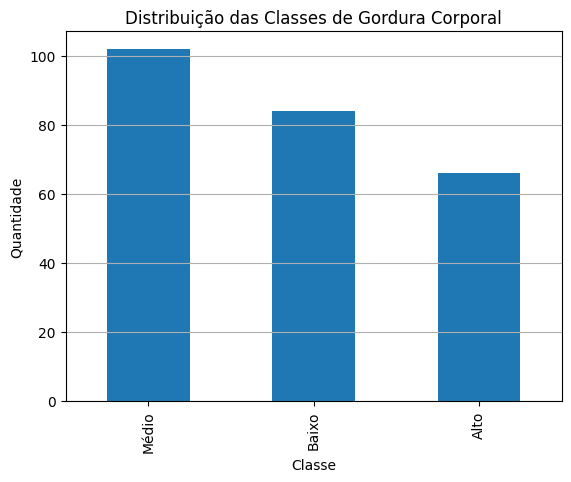

In [ ]:
# Plot do gráfico de distribução de BF
df["classe_gordura"].value_counts().plot(kind="bar")

plt.title("Distribuição das Classes de Gordura Corporal")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.grid(axis='y')

plt.show()

### Separação treino e teste

Separacao dos Dados

In [ ]:
# Separar X e y
X = df.drop(columns=["class", "classe_gordura"])
y = df["classe_gordura"]

print(X.shape)
print(y.shape)

(252, 14)
(252,)


In [ ]:
# Divisão de treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(176, 14)
(76, 14)


### Normalização dos Dados

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled[:5])

[[ 0.94678297 -0.41812136 -1.46859654 -0.62182744 -1.68873178 -1.43776482
  -1.68133761 -1.49697287 -1.12764573 -1.69761922 -0.33055064 -1.38096506
  -1.21626341 -0.94109392]
 [-0.36075444 -0.25237956 -0.7186494  -0.24999857 -0.94520063 -0.33039032
  -0.56501813 -0.46481941 -0.28975583  0.04417238  0.59681779 -0.30030687
  -0.66065087 -0.83679132]
 [ 1.77557636  0.16197494 -1.66638479 -0.80774187 -1.53219891 -1.99145207
  -1.98083796 -1.67123255 -1.64180544 -1.74010194 -0.70149801 -1.74118445
  -1.41830434 -1.46260693]
 [ 1.19387665 -1.32970127 -0.5703082  -0.24999857 -0.47560201 -0.37653092
  -0.79191233 -0.12970465 -0.0612404  -1.35775745 -0.26872608 -0.66052627
  -0.96371225 -0.62818612]
 [-0.74169053 -1.90979757 -0.79281999 -0.93168483 -1.53219891 -0.56109334
  -0.39257854 -0.06268169  0.07206026  0.17162054  0.59681779 -1.0862401
  -1.72136572 -1.67121213]]


### Criação da Rede Neura MLP

In [ ]:
mlp = MLPClassifier(
    hidden_layer_sizes=(16,),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=2000,
    random_state=42
)

### Treinamento

In [ ]:
mlp.fit(X_train_scaled, y_train)

MLPClassifier(hidden_layer_sizes=(16,), max_iter=2000, random_state=42)

### Predições e avaliação

In [ ]:
y_pred = mlp.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)

print("Acurácia:", acc)

print(classification_report(y_test, y_pred))

Acurácia: 0.7368421052631579
              precision    recall  f1-score   support

        Alto       0.70      0.70      0.70        20
       Baixo       0.86      0.76      0.81        25
       Médio       0.68      0.74      0.71        31

    accuracy                           0.74        76
   macro avg       0.75      0.73      0.74        76
weighted avg       0.74      0.74      0.74        76



### Matriz de confusão

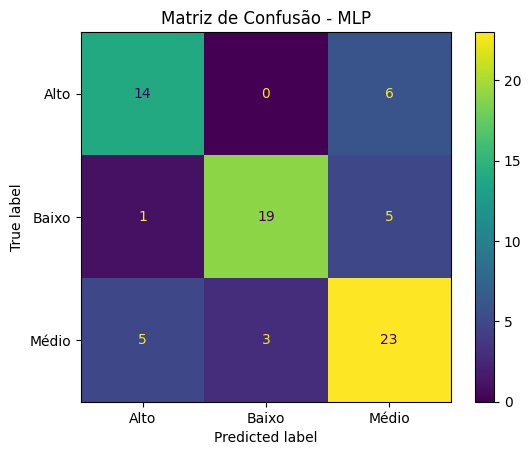

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=mlp.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=mlp.classes_
)

disp.plot()

plt.title("Matriz de Confusão - MLP")

plt.show()

### Curva de Loss

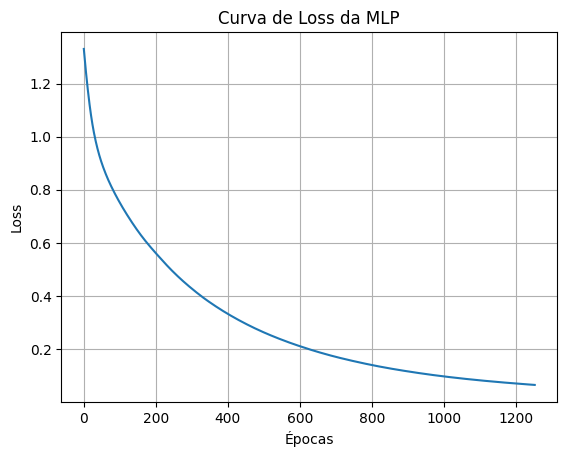

In [ ]:
plt.plot(mlp.loss_curve_)

plt.title("Curva de Loss da MLP")
plt.xlabel("Épocas")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

### Comparação da Quantidade de Neurônios

In [ ]:
resultados = []

for neuronios in [8, 16, 32, 64]:

    modelo = MLPClassifier(
        hidden_layer_sizes=(neuronios,),
        activation='relu',
        solver='adam',
        learning_rate_init=0.001,
        max_iter=2000,
        random_state=42
    )

    modelo.fit(X_train_scaled, y_train)

    pred = modelo.predict(X_test_scaled)

    acc = accuracy_score(y_test, pred)

    resultados.append([neuronios, acc])

resultados_df = pd.DataFrame(
    resultados,
    columns=["Neurônios", "Acurácia"]
)

resultados_df

,Neurônios,Acurácia
0,8,0.842105
1,16,0.736842
2,32,0.789474
3,64,0.855263


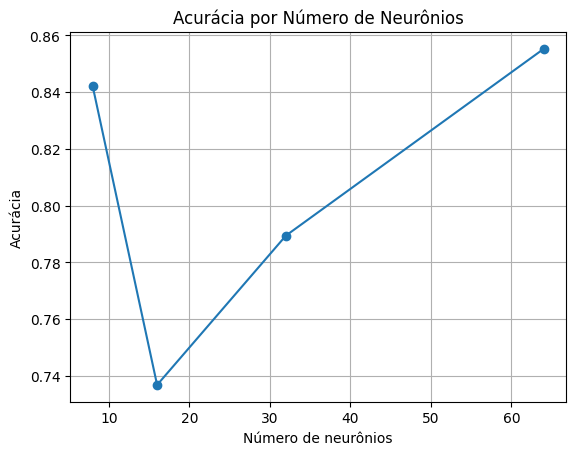

In [ ]:
plt.plot(
    resultados_df["Neurônios"],
    resultados_df["Acurácia"],
    marker='o'
)

plt.title("Acurácia por Número de Neurônios")
plt.xlabel("Número de neurônios")
plt.ylabel("Acurácia")

plt.grid(True)

plt.show()

### Comparação de Learning Rate

In [ ]:
resultados_lr = []

for lr in [0.1, 0.01, 0.001]:

    modelo = MLPClassifier(
        hidden_layer_sizes=(16,),
        activation='relu',
        solver='adam',
        learning_rate_init=lr,
        max_iter=2000,
        random_state=42
    )

    modelo.fit(X_train_scaled, y_train)

    pred = modelo.predict(X_test_scaled)

    acc = accuracy_score(y_test, pred)

    resultados_lr.append([lr, acc])

resultados_lr_df = pd.DataFrame(
    resultados_lr,
    columns=["Learning Rate", "Acurácia"]
)

resultados_lr_df

,Learning Rate,Acurácia
0,0.100,0.894737
1,0.010,0.802632
2,0.001,0.736842


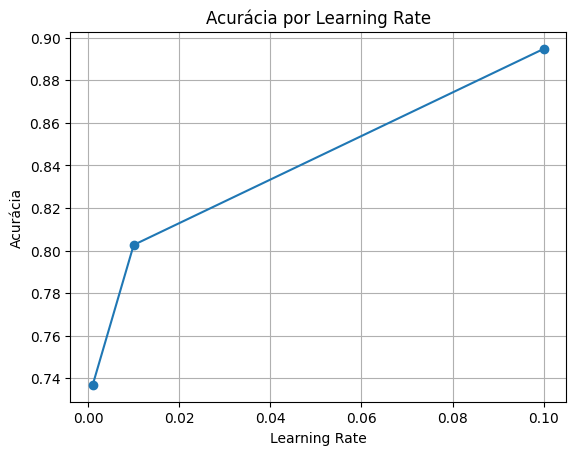

In [ ]:
plt.plot(
    resultados_lr_df["Learning Rate"],
    resultados_lr_df["Acurácia"],
    marker='o'
)

plt.title("Acurácia por Learning Rate")
plt.xlabel("Learning Rate")
plt.ylabel("Acurácia")

plt.grid(True)

plt.show()